# Clustering

### CA5 @ AI Course

*Full Name:* Parham Javan

*SID:* 810800008

### Load the Dataset
We'll start by loading the dataset and inspecting its content.

In [193]:
import pandas as pd

# Load the dataset
file_path = "dataset.csv" 
data = pd.read_csv(file_path, encoding='latin1', header=None, names=["Document"])

# Display the first few rows and dataset information
print("First 5 rows of the dataset:")
print(data.head())

print("\nDataset info:")
print(data.info())

print("\nSample statistics:")
print(data.describe())


First 5 rows of the dataset:
                                            Document
0                                           document
1  From: melabdel@cobra.cs.unm.edu (Mohammed Elab...
2  From: bc744@cleveland.Freenet.Edu (Mark Ira Ka...
3  From: lundby@rtsg.mot.com (Walter F. Lundby)\n...
4  From: ajs8@kimbark.uchicago.edu (adam jeremy s...

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3898 entries, 0 to 3897
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Document  3898 non-null   object
dtypes: object(1)
memory usage: 30.6+ KB
None

Sample statistics:
        Document
count       3898
unique      3898
top     document
freq           1


### Preprocessing
We'll clean the data by:

>Removing stopwords.

>Lowercasing the text.

>Removing unnecessary characters like \n, \r, and punctuation.

>Applying stemming and lemmatization.

In [194]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Download necessary NLTK packages
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initialize tools
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Function to preprocess text
def preprocess_text(text):
    # Remove unwanted characters (e.g., \n, \r, and extra spaces)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    
    # Convert to lowercase
    text = text.lower()
    
    # Tokenize text (split into words)
    words = text.split()
    
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    
    # Apply stemming
    stemmed_words = [stemmer.stem(word) for word in words]
    
    # Apply lemmatization
    lemmatized_words = [lemmatizer.lemmatize(word) for word in stemmed_words]
    
    # Join the words back into a single string
    return ' '.join(lemmatized_words)

# Apply preprocessing to the dataset
data['Processed_Document'] = data['Document'].apply(preprocess_text)

# Display the processed data
print(data.head())


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


                                            Document  \
0                                           document   
1  From: melabdel@cobra.cs.unm.edu (Mohammed Elab...   
2  From: bc744@cleveland.Freenet.Edu (Mark Ira Ka...   
3  From: lundby@rtsg.mot.com (Walter F. Lundby)\n...   
4  From: ajs8@kimbark.uchicago.edu (adam jeremy s...   

                                  Processed_Document  
0                                           document  
1  melabdelcobracsunmedu moham elabdellaoui subje...  
2  bc744clevelandfreenetedu mark ira kaufman subj...  
3  lundbyrtsgmotcom walter f lundbi subject msg s...  
4  ajs8kimbarkuchicagoedu adam jeremi schorr subj...  


### Feature Extraction
Once preprocessing is complete, we extract features using TF-IDF Vectorizer or sentence embeddings.

> 1.TF-IDF Vectorizer (Term Frequency-Inverse Document Frequency)

In [195]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=500)  # Adjust max_features as needed

# Apply TF-IDF transformation
tfidf_features = tfidf.fit_transform(data['Processed_Document'])

# Convert to DataFrame for easier viewing
tfidf_df = pd.DataFrame(tfidf_features.toarray(), columns=tfidf.get_feature_names_out())

print("TF-IDF Features:")
print(tfidf_df.head())


TF-IDF Features:
    10   11        12   13   14   15   16  1992  1993   20  ...     would  \
0  0.0  0.0  0.000000  0.0  0.0  0.0  0.0   0.0   0.0  0.0  ...  0.000000   
1  0.0  0.0  0.000000  0.0  0.0  0.0  0.0   0.0   0.0  0.0  ...  0.106355   
2  0.0  0.0  0.152894  0.0  0.0  0.0  0.0   0.0   0.0  0.0  ...  0.343574   
3  0.0  0.0  0.070785  0.0  0.0  0.0  0.0   0.0   0.0  0.0  ...  0.000000   
4  0.0  0.0  0.000000  0.0  0.0  0.0  0.0   0.0   0.0  0.0  ...  0.000000   

      write  wrong  wrote   ye  year  yet  york  young  your  
0  0.000000    0.0    0.0  0.0   0.0  0.0   0.0    0.0   0.0  
1  0.082984    0.0    0.0  0.0   0.0  0.0   0.0    0.0   0.0  
2  0.000000    0.0    0.0  0.0   0.0  0.0   0.0    0.0   0.0  
3  0.000000    0.0    0.0  0.0   0.0  0.0   0.0    0.0   0.0  
4  0.000000    0.0    0.0  0.0   0.0  0.0   0.0    0.0   0.0  

[5 rows x 500 columns]


> 2.Sentence Embeddings (Using Hugging Face)

In [196]:
from sentence_transformers import SentenceTransformer

# Load the pre-trained SentenceTransformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate sentence embeddings
sentence_embeddings = model.encode(data['Processed_Document'])

print("Sentence Embeddings Shape:", sentence_embeddings.shape)


Sentence Embeddings Shape: (3898, 384)


### Extract Feature Vectors Using SentenceTransformers
We'll use all-MiniLM-L6-v2 to convert text data into feature vectors.

In [197]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd

# Load the dataset
file_path = "dataset.csv"  # Replace with your dataset path
data = pd.read_csv(file_path, encoding='latin1', header=None, names=["Document"])

# Load the SentenceTransformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Extract feature vectors for each document
data['Feature_Vector'] = data['Document'].apply(lambda x: model.encode(x))

# Convert feature vectors to a 2D array for clustering
feature_matrix = np.array(data['Feature_Vector'].tolist())

print("Feature Matrix Shape:", feature_matrix.shape)

Feature Matrix Shape: (3898, 384)


### K-Means Clustering with Elbow Method
K-Means Implementation and Elbow Method

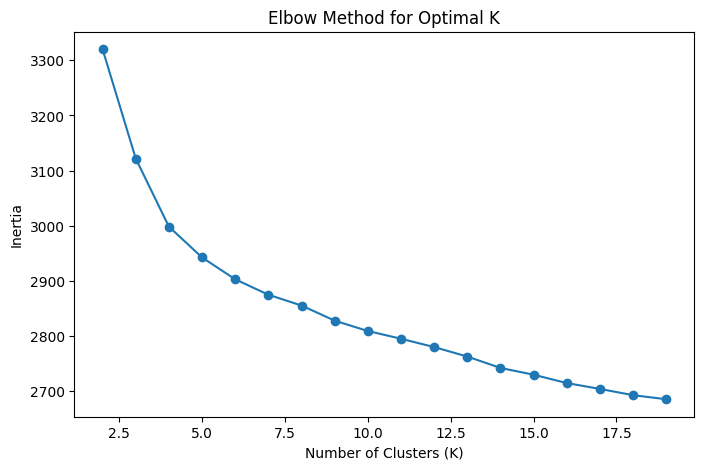

                                            Document  KMeans_Cluster1
0                                           document                2
1  From: melabdel@cobra.cs.unm.edu (Mohammed Elab...                0
2  From: bc744@cleveland.Freenet.Edu (Mark Ira Ka...                0
3  From: lundby@rtsg.mot.com (Walter F. Lundby)\n...                2
4  From: ajs8@kimbark.uchicago.edu (adam jeremy s...                2


In [198]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Elbow Method to determine optimal K
inertia = []
K_range = range(2, 20)  # Test K values from 2 to 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(feature_matrix)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

# Fit K-Means with optimal K (e.g., based on elbow method)
optimal_k = 3  # value when inertia flatens
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['KMeans_Cluster1'] = kmeans.fit_predict(feature_matrix)

# Fit K-Means with optimal K (e.g., based on elbow method)
optimal_k = 4  # value when inertia flatens
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['KMeans_Cluster'] = data['KMeans_Cluster2'] = kmeans.fit_predict(feature_matrix)

# Fit K-Means with optimal K (e.g., based on elbow method)
optimal_k = 5  # value when inertia flatens
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['KMeans_Cluster3'] = kmeans.fit_predict(feature_matrix)

# Fit K-Means with optimal K (e.g., based on elbow method)
optimal_k = 6  # value when inertia flatens
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['KMeans_Cluster4'] = kmeans.fit_predict(feature_matrix)

# Fit K-Means with optimal K (e.g., based on elbow method)
optimal_k = 7  # value when inertia flatens
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['KMeans_Cluster5'] = kmeans.fit_predict(feature_matrix)

# Fit K-Means with optimal K (e.g., based on elbow method)
optimal_k = 8  # value when inertia flatens
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['KMeans_Cluster6'] = kmeans.fit_predict(feature_matrix)

print(data[['Document', 'KMeans_Cluster1']].head())


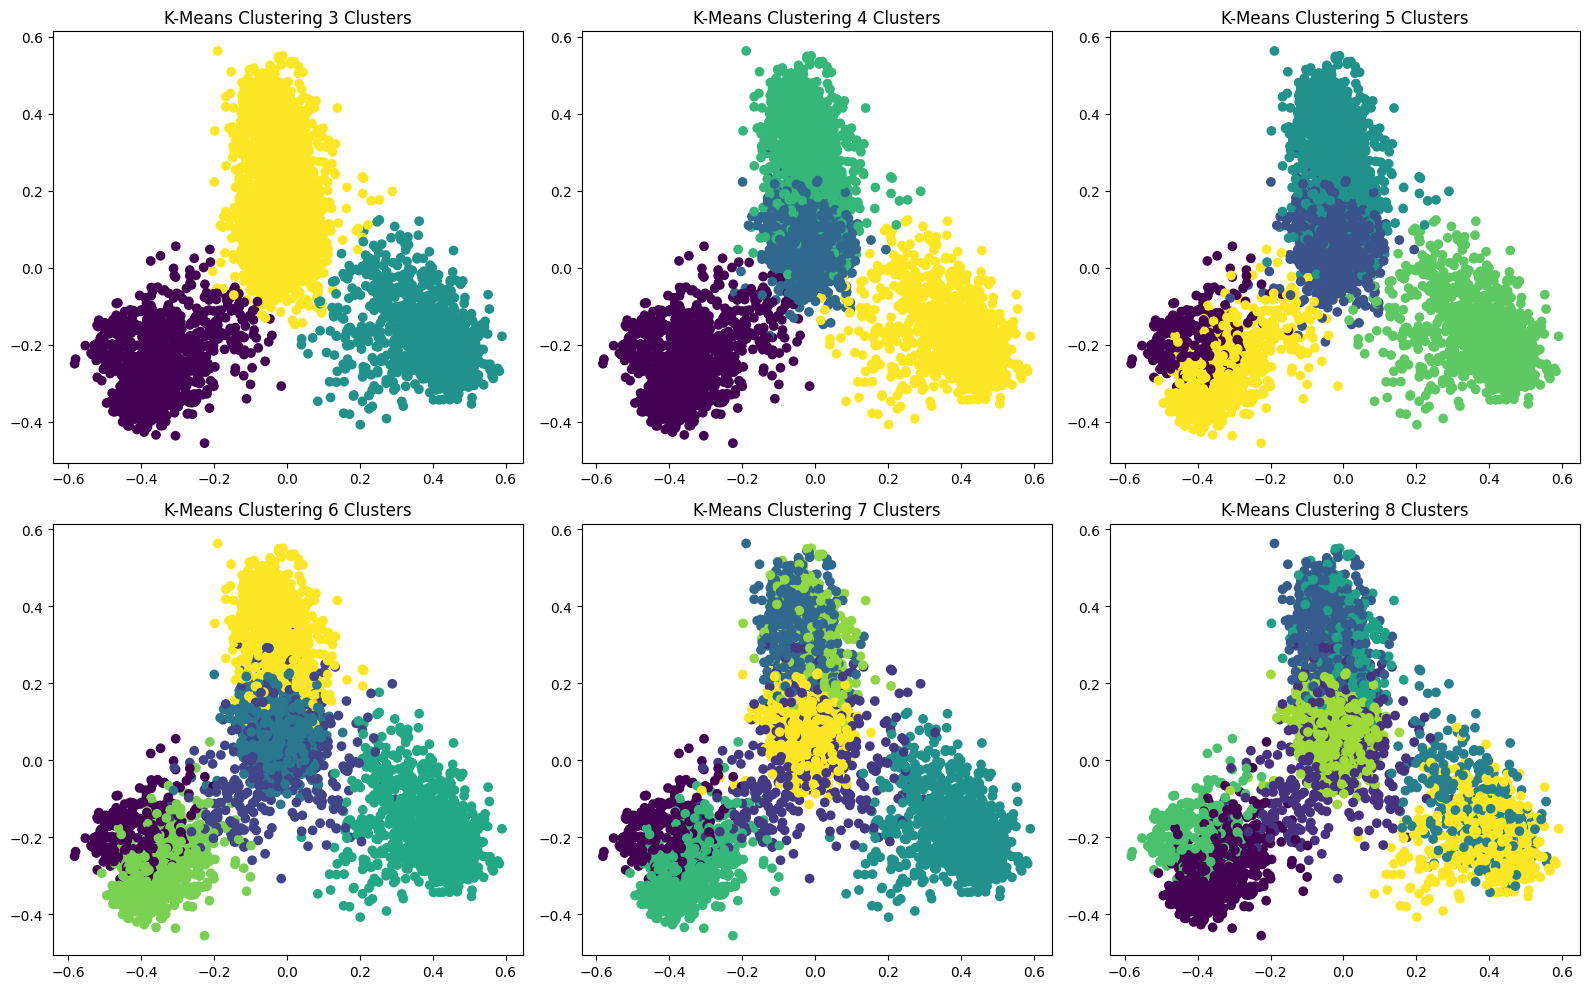

In [216]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced_features = pca.fit_transform(feature_matrix)

plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['KMeans_Cluster1'], cmap='viridis')
plt.title("K-Means Clustering 3 Clusters")

plt.subplot(2, 3, 2)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['KMeans_Cluster2'], cmap='viridis')
plt.title("K-Means Clustering 4 Clusters")

plt.subplot(2, 3, 3)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['KMeans_Cluster3'], cmap='viridis')
plt.title("K-Means Clustering 5 Clusters")

plt.subplot(2, 3, 4)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['KMeans_Cluster4'], cmap='viridis')
plt.title("K-Means Clustering 6 Clusters")

plt.subplot(2, 3, 5)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['KMeans_Cluster5'], cmap='viridis')
plt.title("K-Means Clustering 7 Clusters")

# Plot for 8 clusters
plt.subplot(2, 3, 6)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['KMeans_Cluster6'], cmap='viridis')
plt.title("K-Means Clustering 8 Clusters")

plt.tight_layout()  # Adjust layout for better spacing
plt.show()


### DBSCAN Clustering
DBSCAN Implementation

In [200]:
from sklearn.cluster import DBSCAN

# Fit DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)  # Adjust eps and min_samples based on trial and error
data['DBSCAN_Cluster1'] = dbscan.fit_predict(feature_matrix)

# Fit DBSCAN
dbscan = DBSCAN(eps=0.75, min_samples=5)  # Adjust eps and min_samples based on trial and error
data['DBSCAN_Cluster2'] = dbscan.fit_predict(feature_matrix)

# Fit DBSCAN
dbscan = DBSCAN(eps=1, min_samples=5)  # Adjust eps and min_samples based on trial and error
data['DBSCAN_Cluster3'] = dbscan.fit_predict(feature_matrix)

# Fit DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=10)  # Adjust eps and min_samples based on trial and error
data['DBSCAN_Cluster4'] = dbscan.fit_predict(feature_matrix)

# Fit DBSCAN
dbscan = DBSCAN(eps=0.75, min_samples=10)  # Adjust eps and min_samples based on trial and error
data['DBSCAN_Cluster5'] = dbscan.fit_predict(feature_matrix)

# Fit DBSCAN
dbscan = DBSCAN(eps=1, min_samples=10)  # Adjust eps and min_samples based on trial and error
data['DBSCAN_Cluster6'] = dbscan.fit_predict(feature_matrix)


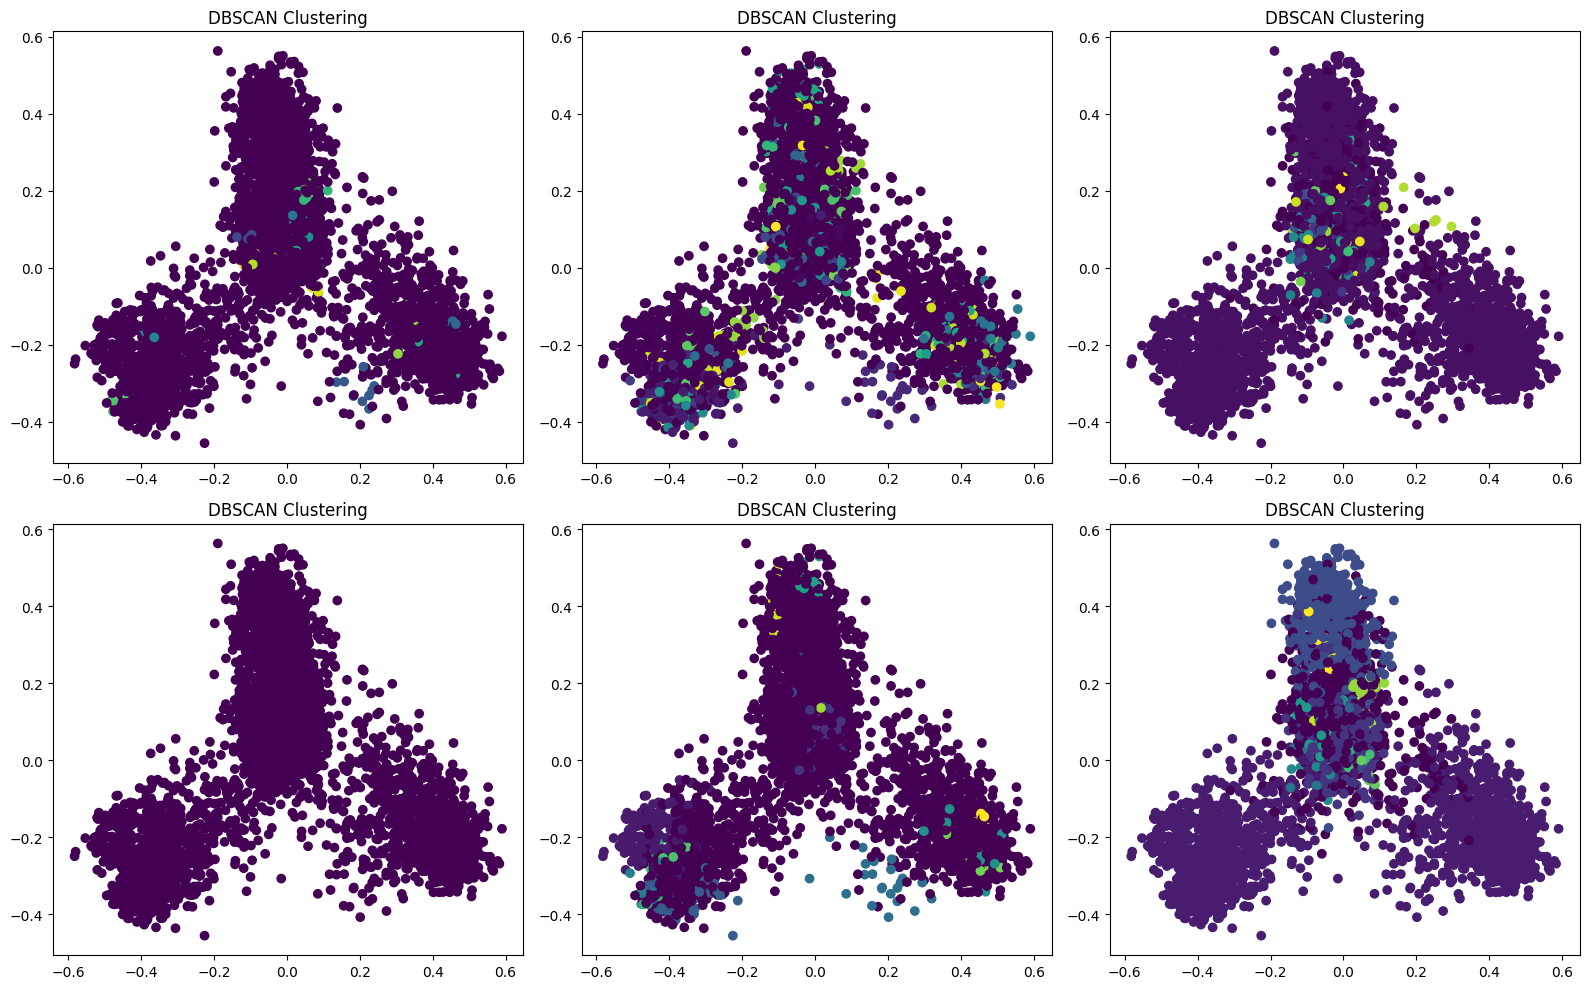

In [201]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Assuming data contains the cluster labels for each method
# Make sure 'KMeans_Cluster1', 'KMeans_Cluster2', ... are the actual cluster labels

# Reduce feature matrix to 2D for visualization
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(feature_matrix)

# Plot clusters for each K-Means method
plt.figure(figsize=(16, 10))

# Plot for 3 clusters
plt.subplot(2, 3, 1)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['DBSCAN_Cluster1'], cmap='viridis')
plt.title("DBSCAN Clustering")


# Plot for 4 clusters
plt.subplot(2, 3, 2)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['DBSCAN_Cluster2'], cmap='viridis')
plt.title("DBSCAN Clustering")

# Plot for 5 clusters
plt.subplot(2, 3, 3)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['DBSCAN_Cluster3'], cmap='viridis')
plt.title("DBSCAN Clustering")

# Plot for 6 clusters
plt.subplot(2, 3, 4)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['DBSCAN_Cluster4'], cmap='viridis')
plt.title("DBSCAN Clustering")

# Plot for 7 clusters
plt.subplot(2, 3, 5)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['DBSCAN_Cluster5'], cmap='viridis')
plt.title("DBSCAN Clustering")

# Plot for 8 clusters
plt.subplot(2, 3, 6)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['DBSCAN_Cluster6'], cmap='viridis')
plt.title("DBSCAN Clustering")

plt.tight_layout()  # Adjust layout for better spacing
plt.show()


In [202]:
from sklearn.cluster import DBSCAN

# Fit DBSCAN
dbscan = DBSCAN(eps=1, min_samples=15)  # Adjust eps and min_samples based on trial and error
data['DBSCAN_Cluster7'] = dbscan.fit_predict(feature_matrix)

# Fit DBSCAN
dbscan = DBSCAN(eps=1, min_samples=30)  # Adjust eps and min_samples based on trial and error
data['DBSCAN_Cluster8'] = dbscan.fit_predict(feature_matrix)

# Fit DBSCAN
dbscan = DBSCAN(eps=2, min_samples=15)  # Adjust eps and min_samples based on trial and error
data['DBSCAN_Cluster9'] = dbscan.fit_predict(feature_matrix)

# Fit DBSCAN
dbscan = DBSCAN(eps=2, min_samples=30)  # Adjust eps and min_samples based on trial and error
data['DBSCAN_Cluster10'] = dbscan.fit_predict(feature_matrix)

# Fit DBSCAN
dbscan = DBSCAN(eps=3, min_samples=15)  # Adjust eps and min_samples based on trial and error
data['DBSCAN_Cluster11'] = dbscan.fit_predict(feature_matrix)

# Fit DBSCAN
dbscan = DBSCAN(eps=3, min_samples=30)  # Adjust eps and min_samples based on trial and error
data['DBSCAN_Cluster12'] = dbscan.fit_predict(feature_matrix)

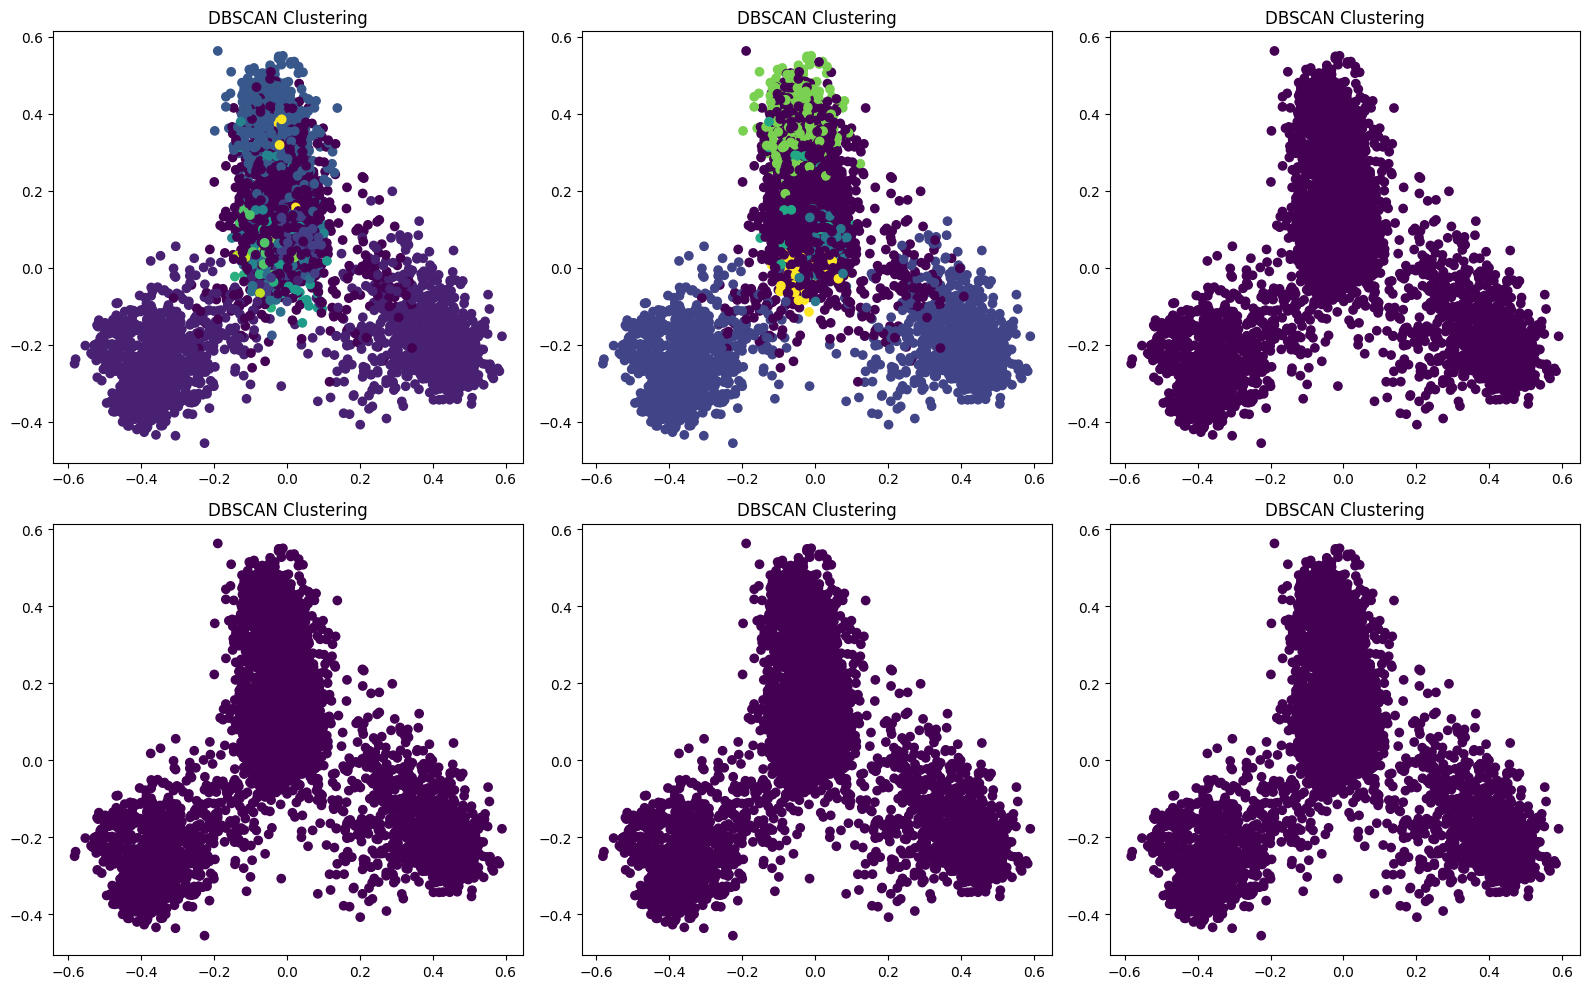

In [203]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Assuming data contains the cluster labels for each method
# Make sure 'KMeans_Cluster1', 'KMeans_Cluster2', ... are the actual cluster labels

# Reduce feature matrix to 2D for visualization
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(feature_matrix)

# Plot clusters for each K-Means method
plt.figure(figsize=(16, 10))

# Plot for 3 clusters
plt.subplot(2, 3, 1)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['DBSCAN_Cluster7'], cmap='viridis')
plt.title("DBSCAN Clustering")


# Plot for 4 clusters
plt.subplot(2, 3, 2)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['DBSCAN_Cluster8'], cmap='viridis')
plt.title("DBSCAN Clustering")

# Plot for 5 clusters
plt.subplot(2, 3, 3)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['DBSCAN_Cluster9'], cmap='viridis')
plt.title("DBSCAN Clustering")

# Plot for 6 clusters
plt.subplot(2, 3, 4)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['DBSCAN_Cluster10'], cmap='viridis')
plt.title("DBSCAN Clustering")

# Plot for 7 clusters
plt.subplot(2, 3, 5)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['DBSCAN_Cluster11'], cmap='viridis')
plt.title("DBSCAN Clustering")

# Plot for 8 clusters
plt.subplot(2, 3, 6)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['DBSCAN_Cluster12'], cmap='viridis')
plt.title("DBSCAN Clustering")

plt.tight_layout()  # Adjust layout for better spacing
plt.show()


In [204]:
from sklearn.cluster import DBSCAN

# Fit DBSCAN
dbscan = DBSCAN(eps=1.05, min_samples=24)  # Adjust eps and min_samples based on trial and error
data['DBSCAN_Cluster7'] = dbscan.fit_predict(feature_matrix)

# Fit DBSCAN
dbscan = DBSCAN(eps=1.05, min_samples=26)  # Adjust eps and min_samples based on trial and error
data['DBSCAN_Cluster8'] = dbscan.fit_predict(feature_matrix)

# Fit DBSCAN
dbscan = DBSCAN(eps=1.05, min_samples=28)  # Adjust eps and min_samples based on trial and error
data['DBSCAN_Cluster9'] = dbscan.fit_predict(feature_matrix)

# Fit DBSCAN
dbscan = DBSCAN(eps=1.05, min_samples=30)  # Adjust eps and min_samples based on trial and error
data['DBSCAN_Cluster'] =  data['DBSCAN_Cluster10'] = dbscan.fit_predict(feature_matrix)

# Fit DBSCAN
dbscan = DBSCAN(eps=1.05, min_samples=32)  # Adjust eps and min_samples based on trial and error
data['DBSCAN_Cluster11'] = dbscan.fit_predict(feature_matrix)

# Fit DBSCAN
dbscan = DBSCAN(eps=1.05, min_samples=34)  # Adjust eps and min_samples based on trial and error
data['DBSCAN_Cluster12'] = dbscan.fit_predict(feature_matrix)

print(data[['Document', 'DBSCAN_Cluster']].head())

                                            Document  DBSCAN_Cluster
0                                           document              -1
1  From: melabdel@cobra.cs.unm.edu (Mohammed Elab...               0
2  From: bc744@cleveland.Freenet.Edu (Mark Ira Ka...               0
3  From: lundby@rtsg.mot.com (Walter F. Lundby)\n...               1
4  From: ajs8@kimbark.uchicago.edu (adam jeremy s...               2


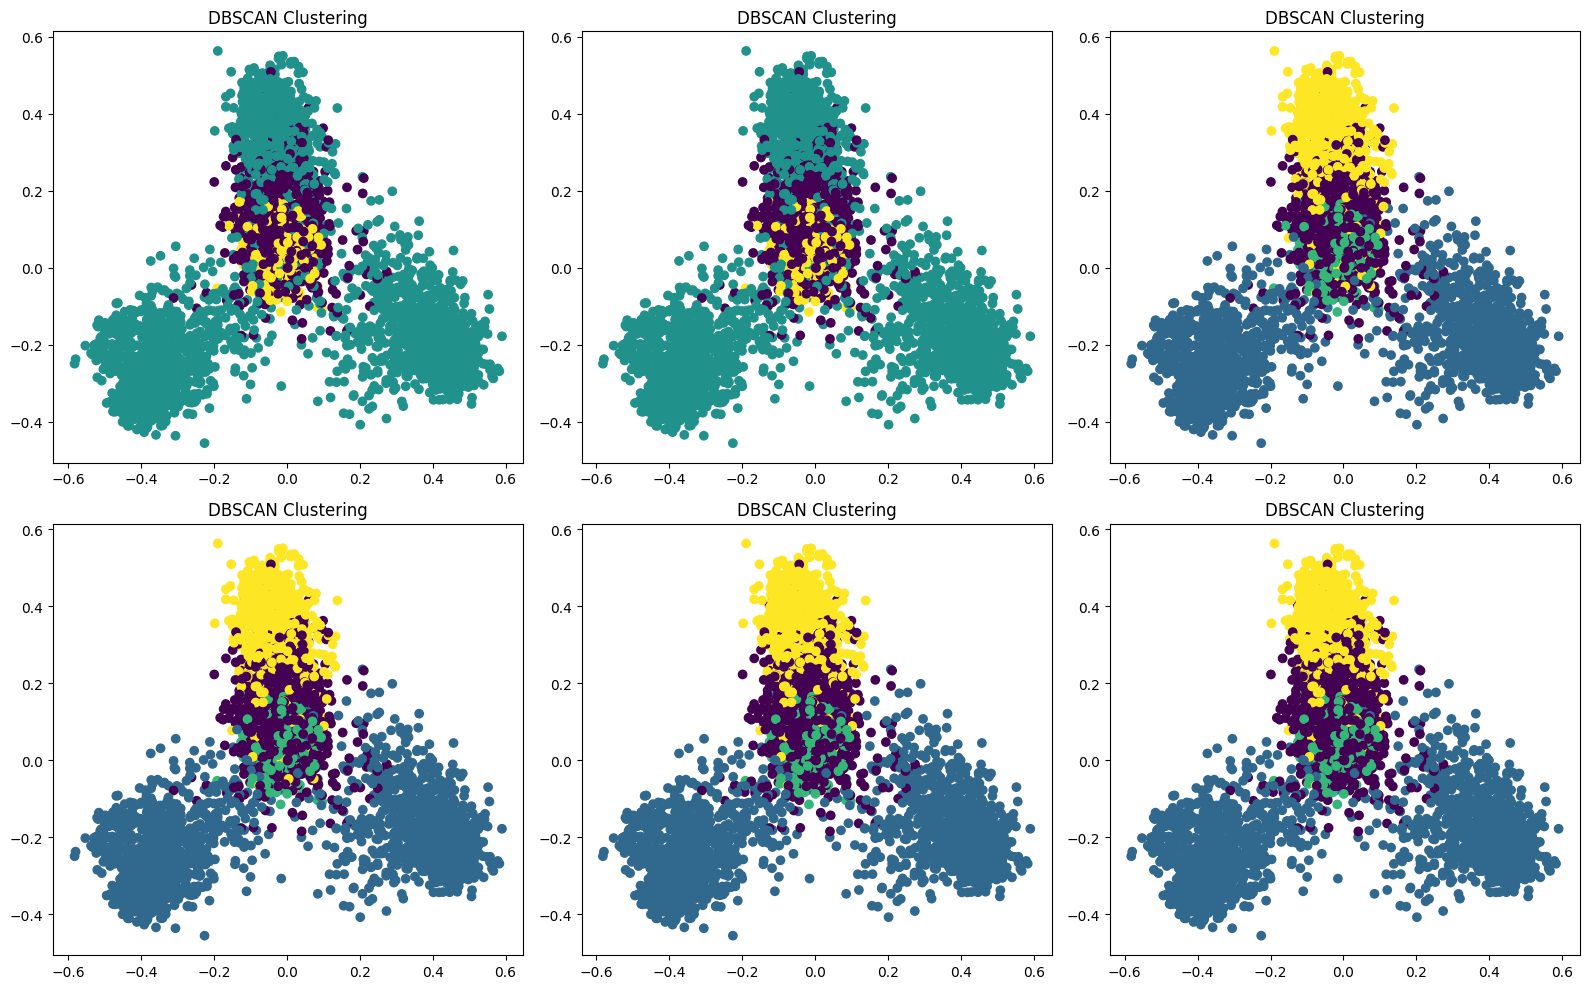

In [205]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


pca = PCA(n_components=2)
reduced_features = pca.fit_transform(feature_matrix)

plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['DBSCAN_Cluster7'], cmap='viridis')
plt.title("DBSCAN Clustering")


plt.subplot(2, 3, 2)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['DBSCAN_Cluster8'], cmap='viridis')
plt.title("DBSCAN Clustering")

plt.subplot(2, 3, 3)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['DBSCAN_Cluster9'], cmap='viridis')
plt.title("DBSCAN Clustering")

# Plot for 6 clusters
plt.subplot(2, 3, 4)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['DBSCAN_Cluster10'], cmap='viridis')
plt.title("DBSCAN Clustering")

plt.subplot(2, 3, 5)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['DBSCAN_Cluster11'], cmap='viridis')
plt.title("DBSCAN Clustering")

plt.subplot(2, 3, 6)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['DBSCAN_Cluster12'], cmap='viridis')
plt.title("DBSCAN Clustering")

plt.tight_layout()  # Adjust layout for better spacing
plt.show()


### Hierarchical Clustering
Hierarchical Clustering Implementation

In [206]:
from sklearn.cluster import AgglomerativeClustering

# Fit Hierarchical Clustering
optimal_k = 3
hierarchical = AgglomerativeClustering(n_clusters=optimal_k)  # Replace optimal_k with your chosen value
data['Hierarchical_Cluster1'] = hierarchical.fit_predict(feature_matrix)

# Fit Hierarchical Clustering
optimal_k = 4
hierarchical = AgglomerativeClustering(n_clusters=optimal_k)  # Replace optimal_k with your chosen value
data['Hierarchical_Cluster'] = data['Hierarchical_Cluster2'] = hierarchical.fit_predict(feature_matrix)

# Fit Hierarchical Clustering
optimal_k = 5
hierarchical = AgglomerativeClustering(n_clusters=optimal_k)  # Replace optimal_k with your chosen value
data['Hierarchical_Cluster3'] = hierarchical.fit_predict(feature_matrix)

# Fit Hierarchical Clustering
optimal_k = 6
hierarchical = AgglomerativeClustering(n_clusters=optimal_k)  # Replace optimal_k with your chosen value
data['Hierarchical_Cluster4'] = hierarchical.fit_predict(feature_matrix)

# Fit Hierarchical Clustering
optimal_k = 7
hierarchical = AgglomerativeClustering(n_clusters=optimal_k)  # Replace optimal_k with your chosen value
data['Hierarchical_Cluster5'] = hierarchical.fit_predict(feature_matrix)

# Fit Hierarchical Clustering
optimal_k = 8
hierarchical = AgglomerativeClustering(n_clusters=optimal_k)  # Replace optimal_k with your chosen value
data['Hierarchical_Cluster6'] = hierarchical.fit_predict(feature_matrix)


print(data[['Document', 'Hierarchical_Cluster']].head())


                                            Document  Hierarchical_Cluster
0                                           document                     1
1  From: melabdel@cobra.cs.unm.edu (Mohammed Elab...                     0
2  From: bc744@cleveland.Freenet.Edu (Mark Ira Ka...                     0
3  From: lundby@rtsg.mot.com (Walter F. Lundby)\n...                     2
4  From: ajs8@kimbark.uchicago.edu (adam jeremy s...                     1


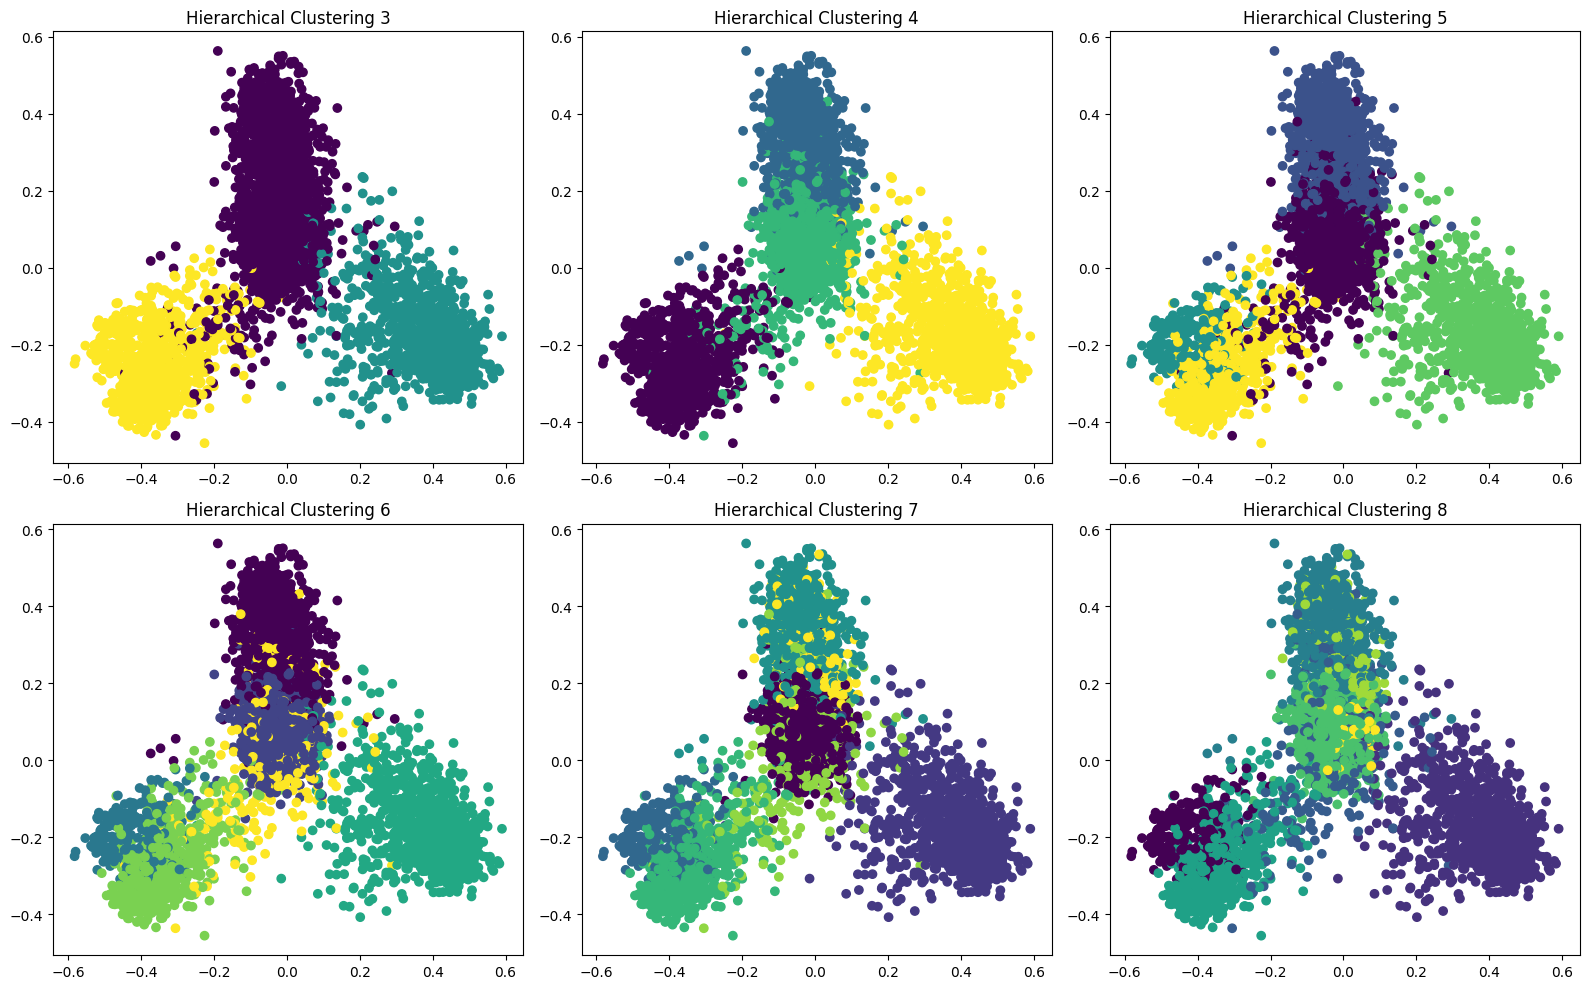

In [207]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Assuming data contains the cluster labels for each method
# Make sure 'KMeans_Cluster1', 'KMeans_Cluster2', ... are the actual cluster labels

# Reduce feature matrix to 2D for visualization
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(feature_matrix)

# Plot clusters for each K-Means method
plt.figure(figsize=(16, 10))

# Plot for 3 clusters
plt.subplot(2, 3, 1)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['Hierarchical_Cluster1'], cmap='viridis')
plt.title("Hierarchical Clustering 3")

# Plot for 4 clusters
plt.subplot(2, 3, 2)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['Hierarchical_Cluster2'], cmap='viridis')
plt.title("Hierarchical Clustering 4")

# Plot for 5 clusters
plt.subplot(2, 3, 3)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['Hierarchical_Cluster3'], cmap='viridis')
plt.title("Hierarchical Clustering 5")

# Plot for 6 clusters
plt.subplot(2, 3, 4)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['Hierarchical_Cluster4'], cmap='viridis')
plt.title("Hierarchical Clustering 6")

# Plot for 7 clusters
plt.subplot(2, 3, 5)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['Hierarchical_Cluster5'], cmap='viridis')
plt.title("Hierarchical Clustering 7")

# Plot for 8 clusters
plt.subplot(2, 3, 6)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['Hierarchical_Cluster6'], cmap='viridis')
plt.title("Hierarchical Clustering 8")

plt.tight_layout()  # Adjust layout for better spacing
plt.show()

### Compare Clustering Outputs
Visualize and compare the clustering results using PCA for dimensionality reduction:

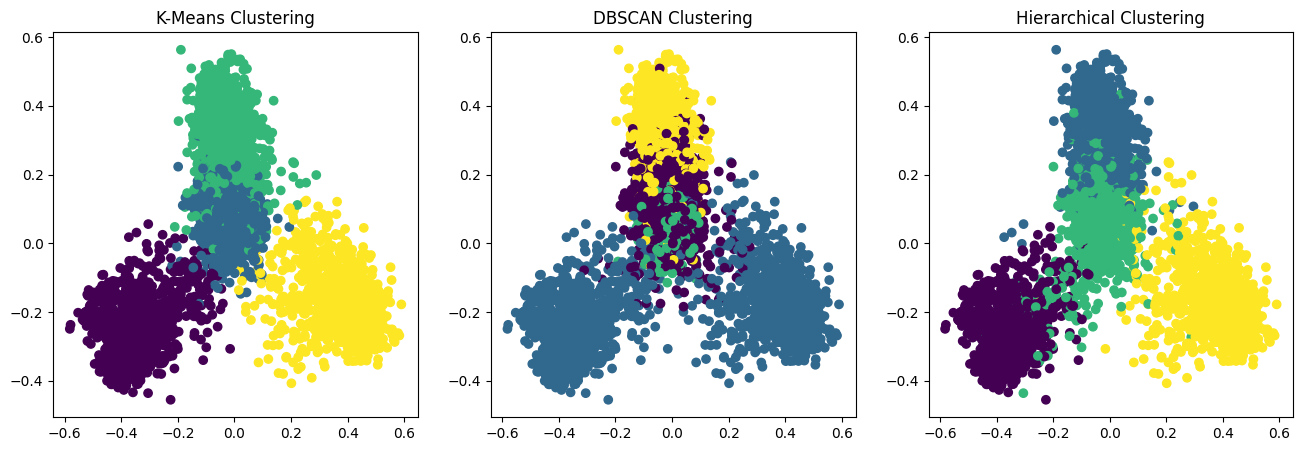

In [208]:
from sklearn.decomposition import PCA

# Reduce feature matrix to 2D for visualization
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(feature_matrix)

# Plot clusters for each method
plt.figure(figsize=(16, 5))

# K-Means
plt.subplot(1, 3, 1)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['KMeans_Cluster'], cmap='viridis')
plt.title("K-Means Clustering")

# DBSCAN
plt.subplot(1, 3, 2)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['DBSCAN_Cluster'], cmap='viridis')
plt.title("DBSCAN Clustering")

# Hierarchical
plt.subplot(1, 3, 3)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['Hierarchical_Cluster'], cmap='viridis')
plt.title("Hierarchical Clustering")

plt.show()


Let's address dimensionality reduction with PCA (Principal Component Analysis) and visualize the clusters obtained from the three clustering algorithms (K-Means, DBSCAN, Hierarchical Clustering).

## What is PCA?
Principal Component Analysis (PCA) is a dimensionality reduction technique that projects high-dimensional data into a lower-dimensional space. It works by:

Identifying the directions (principal components) in the data where variance is maximized.
Transforming the data into a new coordinate system based on these principal components, while preserving as much variance as possible.
This is especially useful for visualizing high-dimensional data in 2D or 3D.



### Reduce Dimensions with PCA
We will use sklearn's PCA to reduce the feature vectors into 2D space.

In [209]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply PCA to reduce to 2D
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(feature_matrix)

print("Reduced Feature Matrix Shape:", reduced_features.shape)


Reduced Feature Matrix Shape: (3898, 2)


### Visualize Clusters for Each Algorithm
We’ll visualize the clusters generated by K-Means, DBSCAN, and Hierarchical Clustering in the 2D space.

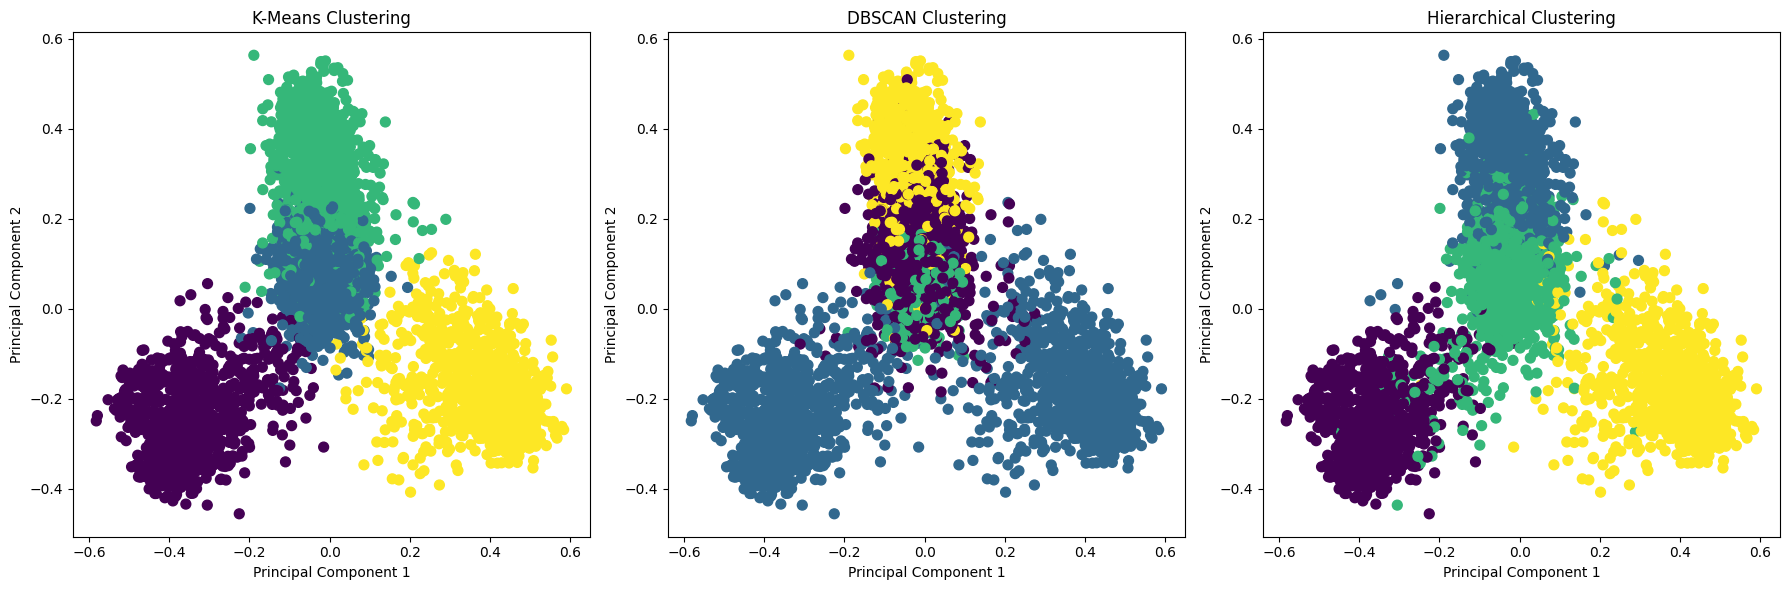

In [210]:
# Plot clusters for K-Means
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['KMeans_Cluster'], cmap='viridis', s=50)
plt.title("K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Plot clusters for DBSCAN
plt.subplot(1, 3, 2)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['DBSCAN_Cluster'], cmap='viridis', s=50)
plt.title("DBSCAN Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Plot clusters for Hierarchical Clustering
plt.subplot(1, 3, 3)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['Hierarchical_Cluster'], cmap='viridis', s=50)
plt.title("Hierarchical Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.tight_layout()
plt.show()


### Silhouette Score for Clustering
The silhouette score measures how similar a data point is to its own cluster compared to other clusters. It ranges from -1 to 1:

1: Well-clustered.
0: Overlapping clusters.
-1: Misclustered.

In [211]:
from sklearn.metrics import silhouette_score

# Calculate silhouette score for K-Means
kmeans_silhouette = silhouette_score(feature_matrix, data['KMeans_Cluster'])
print(f"K-Means Silhouette Score: {kmeans_silhouette}")

# Calculate silhouette score for DBSCAN
dbscan_silhouette = silhouette_score(feature_matrix, data['DBSCAN_Cluster'])
print(f"DBSCAN Silhouette Score: {dbscan_silhouette}")

# Calculate silhouette score for Hierarchical Clustering
hierarchical_silhouette = silhouette_score(feature_matrix, data['Hierarchical_Cluster'])
print(f"Hierarchical Clustering Silhouette Score: {hierarchical_silhouette}")


K-Means Silhouette Score: 0.09170626103878021
DBSCAN Silhouette Score: 0.041474830359220505
Hierarchical Clustering Silhouette Score: 0.08546441793441772


### Visualize Silhouette Scores for Each Method
Create a bar chart to compare silhouette scores across methods.

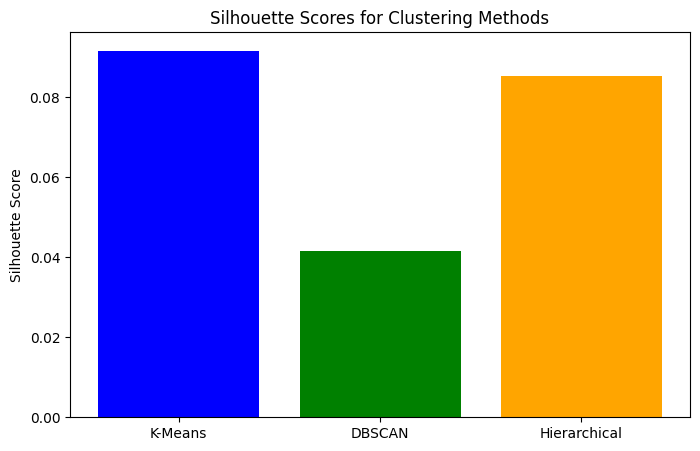

In [212]:
methods = ['K-Means', 'DBSCAN', 'Hierarchical']
scores = [kmeans_silhouette, dbscan_silhouette, hierarchical_silhouette]

plt.figure(figsize=(8, 5))
plt.bar(methods, scores, color=['blue', 'green', 'orange'])
plt.title("Silhouette Scores for Clustering Methods")
plt.ylabel("Silhouette Score")
plt.show()


### Extract Sample Documents from Each Cluster
Print three sample documents from each cluster for each algorithm to evaluate the clustering quality.

In [213]:
def print_cluster_samples(data, cluster_column, num_samples=3):
    clusters = data[cluster_column].unique()
    print(f"\nCluster Samples for {cluster_column}:\n")
    for cluster in clusters:
        if cluster == -1:  # Skip noise in DBSCAN
            continue
        print(f"\nCluster {cluster}:\n")
        samples = data[data[cluster_column] == cluster]['Document'].sample(n=min(num_samples, len(data[data[cluster_column] == cluster])))
        for sample in samples:
            print(sample)
            print("-" * 80)

# Print samples for each clustering method
print_cluster_samples(data, 'KMeans_Cluster')
print_cluster_samples(data, 'DBSCAN_Cluster')
print_cluster_samples(data, 'Hierarchical_Cluster')



Cluster Samples for KMeans_Cluster:


Cluster 2:

From: joth@ersys.edmonton.ab.ca (Joe Tham)
Subject: Where can I find SIPP?
Organization: Edmonton Remote Systems #2, Edmonton, AB, Canada
Lines: 11

        I recently got a file describing a library of rendering routines 
called SIPP (SImple Polygon Processor).  Could anyone tell me where I can 
FTP the source code and which is the newest version around?
        Also, I've never used Renderman so I was wondering if Renderman 
is like SIPP?  ie. a library of rendering routines which one uses to make 
a program that creates the image...

                                        Thanks,  Joe Tham

--
Joe Tham              joth@ersys.edmonton.ab.ca 

--------------------------------------------------------------------------------
From: jliddle@rs6000.cmp.ilstu.edu (Jean Liddle)
Subject: Re: HELP: Need 24 bits viewer
Organization: Illinois State University
Keywords: 24 bit
Lines: 23

In article <1993Apr29.041601.8884@labtam.labtam.oz.au> gr

### Homogeneity Score (If True Labels Are Available)
If you have ground truth labels, you can compute the homogeneity score to measure the clustering accuracy relative to the true labels.

In [214]:
from sklearn.metrics import homogeneity_score

# Assuming you have a 'True_Label' column in your data
if 'True_Label' in data.columns:
    kmeans_homogeneity = homogeneity_score(data['True_Label'], data['KMeans_Cluster'])
    dbscan_homogeneity = homogeneity_score(data['True_Label'], data['DBSCAN_Cluster'])
    hierarchical_homogeneity = homogeneity_score(data['True_Label'], data['Hierarchical_Cluster'])

    print(f"K-Means Homogeneity Score: {kmeans_homogeneity}")
    print(f"DBSCAN Homogeneity Score: {dbscan_homogeneity}")
    print(f"Hierarchical Clustering Homogeneity Score: {hierarchical_homogeneity}")
